## **P4: Model Development**

Building and comparing multiple machine learning models for leukemia classification, includes:
- Simple and multiple linear regression models
- Polynomial regression with pipelines
- Ridge and Lasso regularization models
- Neural Network models (using Keras/TensorFlow)
- Model evaluation with R-squared, MSE, and visualizations
- Prediction and decision making
- Model comparison and selection

### **1. Import Required Libraries**
Load essential libraries for model development, evaluation, and visualization.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# set random seeds for reproducibility
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

# set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

### **2. Load and Prepare Data**

In [15]:
# load cleaned data
features_df = pd.read_csv('GSE13164_cleaned_features.csv', index_col=0)
labels_df = pd.read_csv('GSE13164_cleaned_labels.csv')

# combine features with labels
X = features_df.values
y = labels_df['Target_Code'].values
leukemia_types = labels_df['Leukemia_Type'].values
sample_ids = labels_df['Sample_ID'].values

# split data into training & testing sets (80-20 split)
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, np.arange(len(y)), test_size=0.2, random_state=42, stratify=y
)

# standardize features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape}")
print(f"Testing set size: {X_test_scaled.shape}")

Training set size: (778, 1420)
Testing set size: (195, 1420)


### **3. Model 1 - Simple Linear Regression (Baseline)**

In [ ]:
model1_simple_lr = LinearRegression()
model1_simple_lr.fit(X_train_scaled[:, :1], y_train)

# predictions
y_train_pred_m1 = model1_simple_lr.predict(X_train_scaled[:, :1])
y_test_pred_m1 = model1_simple_lr.predict(X_test_scaled[:, :1])

# eval metrics
train_mse_m1 = mean_squared_error(y_train, y_train_pred_m1)
test_mse_m1 = mean_squared_error(y_test, y_test_pred_m1)
train_r2_m1 = r2_score(y_train, y_train_pred_m1)
test_r2_m1 = r2_score(y_test, y_test_pred_m1)

print(f"Training MSE: {train_mse_m1:.6f}")
print(f"Testing MSE:  {test_mse_m1:.6f}")
print(f"Training R²:  {train_r2_m1:.6f}")
print(f"Testing R²:   {test_r2_m1:.6f}")
print(f"Model Coefficients: {model1_simple_lr.coef_}")
print(f"Model Intercept: {model1_simple_lr.intercept_:.6f}")

Training MSE: 0.817679
Testing MSE:  0.833054
Training R²:  0.042449
Testing R²:   0.030280
Model Coefficients: [-0.19039117]
Model Intercept: 0.883033


### **4. Model 2 - Multiple Linear Regression**

Build a linear regression model using all available gene expression features. This captures relationships across the entire feature space.


In [13]:
# Multiple Linear Regression (using all features)
model2_multiple_lr = LinearRegression()
model2_multiple_lr.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_m2 = model2_multiple_lr.predict(X_train_scaled)
y_test_pred_m2 = model2_multiple_lr.predict(X_test_scaled)

# Evaluation metrics
train_mse_m2 = mean_squared_error(y_train, y_train_pred_m2)
test_mse_m2 = mean_squared_error(y_test, y_test_pred_m2)
train_r2_m2 = r2_score(y_train, y_train_pred_m2)
test_r2_m2 = r2_score(y_test, y_test_pred_m2)

print(f"Training MSE: {train_mse_m2:.6f}")
print(f"Testing MSE:  {test_mse_m2:.6f}")
print(f"Training R²:  {train_r2_m2:.6f}")
print(f"Testing R²:   {test_r2_m2:.6f}")
print(f"Model Intercept: {model2_multiple_lr.intercept_:.6f}")
print(f"Number of coefficients: {len(model2_multiple_lr.coef_)}")


Training MSE: 0.000000
Testing MSE:  0.153705
Training R²:  1.000000
Testing R²:   0.821079
Model Intercept: 0.883033
Number of coefficients: 1420


### **5. Model 3 - Polynomial Regression with Pipeline**
Used scikit-learn pipelines to capture non-linear relationships between genes and leukemia types.

In [14]:
# Polynomial Regression (degree 2) with Pipeline
poly_pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('linear_regression', LinearRegression())
])

model3_poly = poly_pipeline.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_m3 = model3_poly.predict(X_train_scaled)
y_test_pred_m3 = model3_poly.predict(X_test_scaled)

# Evaluation metrics
train_mse_m3 = mean_squared_error(y_train, y_train_pred_m3)
test_mse_m3 = mean_squared_error(y_test, y_test_pred_m3)
train_r2_m3 = r2_score(y_train, y_train_pred_m3)
test_r2_m3 = r2_score(y_test, y_test_pred_m3)

print(f"Training MSE: {train_mse_m3:.6f}")
print(f"Testing MSE:  {test_mse_m3:.6f}")
print(f"Training R²:  {train_r2_m3:.6f}")
print(f"Testing R²:   {test_r2_m3:.6f}")
print(f"Polynomial features shape: {model3_poly.named_steps['poly_features'].n_output_features_}")


Training MSE: 0.000000
Testing MSE:  0.032354
Training R²:  1.000000
Testing R²:   0.962338
Polynomial features shape: 1010330


### **6. Model 4 - Ridge Regression (L2 Regularization)**

To reduce overfitting and improve generalization on test data.


In [17]:
# Ridge Regression with hyperparameter tuning
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train)

model4_ridge = ridge_grid.best_estimator_

# Predictions
y_train_pred_m4 = model4_ridge.predict(X_train_scaled)
y_test_pred_m4 = model4_ridge.predict(X_test_scaled)

# Evaluation metrics
train_mse_m4 = mean_squared_error(y_train, y_train_pred_m4)
test_mse_m4 = mean_squared_error(y_test, y_test_pred_m4)
train_r2_m4 = r2_score(y_train, y_train_pred_m4)
test_r2_m4 = r2_score(y_test, y_test_pred_m4)

print(f"Best alpha (regularization): {ridge_grid.best_params_['alpha']}")
print(f"Training MSE: {train_mse_m4:.6f}")
print(f"Testing MSE:  {test_mse_m4:.6f}")
print(f"Training R²:  {train_r2_m4:.6f}")
print(f"Testing R²:   {test_r2_m4:.6f}")


Best alpha (regularization): 100
Training MSE: 0.008942
Testing MSE:  0.067925
Training R²:  0.989528
Testing R²:   0.920932


### **7. Model 5 - Lasso Regression (L1 Regularization)**
To feature selection and improved interpretability.

In [18]:
# lasso reg with hyperparameter tuning
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X_train_scaled, y_train)

model5_lasso = lasso_grid.best_estimator_

# predictions
y_train_pred_m5 = model5_lasso.predict(X_train_scaled)
y_test_pred_m5 = model5_lasso.predict(X_test_scaled)

# evaluation metrics
train_mse_m5 = mean_squared_error(y_train, y_train_pred_m5)
test_mse_m5 = mean_squared_error(y_test, y_test_pred_m5)
train_r2_m5 = r2_score(y_train, y_train_pred_m5)
test_r2_m5 = r2_score(y_test, y_test_pred_m5)

# count non-zero coefficients (selected features)
non_zero_coefs = np.sum(model5_lasso.coef_ != 0)

print(f"Best alpha (regularization): {lasso_grid.best_params_['alpha']}")
print(f"Training MSE: {train_mse_m5:.6f}")
print(f"Testing MSE:  {test_mse_m5:.6f}")
print(f"Training R²:  {train_r2_m5:.6f}")
print(f"Testing R²:   {test_r2_m5:.6f}")
print(f"Selected features: {non_zero_coefs} out of {len(model5_lasso.coef_)}")

Best alpha (regularization): 0.01
Training MSE: 0.044228
Testing MSE:  0.059842
Training R²:  0.948206
Testing R²:   0.930341
Selected features: 203 out of 1420


### **8. Model 6 - Neural Network (Improved Model)**

Build a deep neural network model using Keras/TensorFlow with multiple layers, batch normalization, and dropout for improved performance and generalization.


In [20]:
model6_nn = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    Dense(1, activation='linear')  # Linear activation for regression
])

# compile the model
model6_nn.compile(optimizer=Adam(learning_rate=0.001), 
                   loss='mse', 
                   metrics=['mae'])

# train with early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = model6_nn.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

# predictions
y_train_pred_m6 = model6_nn.predict(X_train_scaled, verbose=0).flatten()
y_test_pred_m6 = model6_nn.predict(X_test_scaled, verbose=0).flatten()

# eval metrics
train_mse_m6 = mean_squared_error(y_train, y_train_pred_m6)
test_mse_m6 = mean_squared_error(y_test, y_test_pred_m6)
train_r2_m6 = r2_score(y_train, y_train_pred_m6)
test_r2_m6 = r2_score(y_test, y_test_pred_m6)

print(f"Training MSE: {train_mse_m6:.6f}")
print(f"Testing MSE:  {test_mse_m6:.6f}")
print(f"Training R²:  {train_r2_m6:.6f}")
print(f"Testing R²:   {test_r2_m6:.6f}")
print(f"Training epochs: {len(history.history['loss'])}")
print("Model Summary:")
model6_nn.summary()


Training MSE: 0.015176
Testing MSE:  0.019580
Training R²:  0.982228
Testing R²:   0.977208
Training epochs: 120
Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │       363,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,224,709 (4.67 MB)

 Trainable params: 407,937 (1.56 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 815,876 (3.11 MB)

### **9. Model Comparison - Performance Summary**

Create a comprehensive comparison table of all models with their evaluation metrics (MSE and R²).


In [27]:
# create comparison df
comparison_df = pd.DataFrame({
    'Model': [
        'Simple LR',
        'Multiple LR',
        'Polynomial (deg=2)',
        'Ridge',
        'Lasso',
        'Neural Network'
    ],
    'Train MSE': [train_mse_m1, train_mse_m2, train_mse_m3, train_mse_m4, train_mse_m5, train_mse_m6],
    'Test MSE': [test_mse_m1, test_mse_m2, test_mse_m3, test_mse_m4, test_mse_m5, test_mse_m6],
    'Train R²': [train_r2_m1, train_r2_m2, train_r2_m3, train_r2_m4, train_r2_m5, train_r2_m6],
    'Test R²': [test_r2_m1, test_r2_m2, test_r2_m3, test_r2_m4, test_r2_m5, test_r2_m6]
})

print(comparison_df.to_string(index=False))

             Model    Train MSE  Test MSE  Train R²  Test R²
         Simple LR 8.176793e-01  0.833054  0.042449 0.030280
       Multiple LR 1.730419e-29  0.153705  1.000000 0.821079
Polynomial (deg=2) 4.880883e-28  0.032354  1.000000 0.962338
             Ridge 8.942474e-03  0.067925  0.989528 0.920932
             Lasso 4.422814e-02  0.059842  0.948206 0.930341
    Neural Network 1.517573e-02  0.019580  0.982228 0.977208


In [28]:
# find d best models
best_test_r2_idx = comparison_df['Test R²'].idxmax()
best_test_mse_idx = comparison_df['Test MSE'].idxmin()

print(f"\nBest Test R²: {comparison_df.loc[best_test_r2_idx, 'Model']} ({comparison_df.loc[best_test_r2_idx, 'Test R²']:.6f})")
print(f"Best Test MSE: {comparison_df.loc[best_test_mse_idx, 'Model']} ({comparison_df.loc[best_test_mse_idx, 'Test MSE']:.6f})")


Best Test R²: Neural Network (0.977208)
Best Test MSE: Neural Network (0.019580)


In [ ]:

# find d best models
best_test_r2_idx = comparison_df['Test R²'].idxmax()
best_test_mse_idx = comparison_df['Test MSE'].idxmin()

print(f"\nBest Test R²: {comparison_df.loc[best_test_r2_idx, 'Model']} ({comparison_df.loc[best_test_r2_idx, 'Test R²']:.6f})")
print(f"Best Test MSE: {comparison_df.loc[best_test_mse_idx, 'Model']} ({comparison_df.loc[best_test_mse_idx, 'Test MSE']:.6f})")


### **10. Visualization - MSE and R² Comparison**

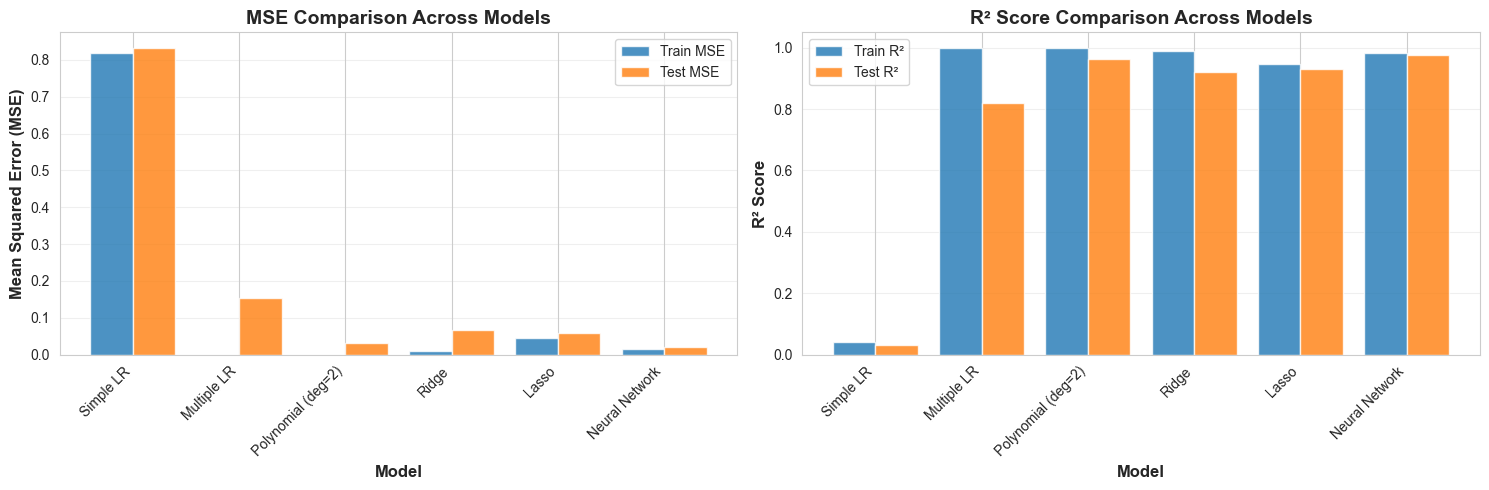

Model comparison visualization saved as 'model_comparison.png'


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MSE comparison
x_pos = np.arange(len(comparison_df))
axes[0].bar(x_pos - 0.2, comparison_df['Train MSE'], 0.4, label='Train MSE', alpha=0.8)
axes[0].bar(x_pos + 0.2, comparison_df['Test MSE'], 0.4, label='Test MSE', alpha=0.8)
axes[0].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean Squared Error (MSE)', fontsize=12, fontweight='bold')
axes[0].set_title('MSE Comparison Across Models', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# R2 comparison
axes[1].bar(x_pos - 0.2, comparison_df['Train R²'], 0.4, label='Train R²', alpha=0.8)
axes[1].bar(x_pos + 0.2, comparison_df['Test R²'], 0.4, label='Test R²', alpha=0.8)
axes[1].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[1].set_title('R² Score Comparison Across Models', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Model comparison visualization saved as 'model_comparison.png'")


### **11. Visualization - Actual vs Predicted Values**

Plot actual vs predicted values for the best-performing model to visualize prediction accuracy.


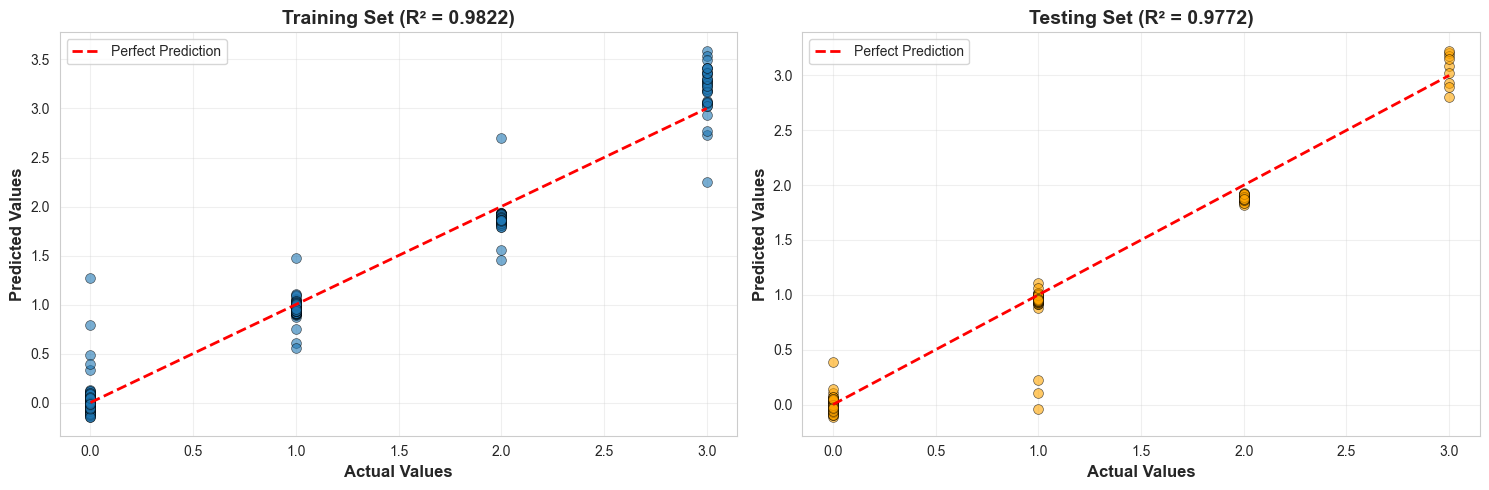

Actual vs Predicted visualization saved as 'actual_vs_predicted.png'


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# training set
axes[0].scatter(y_train, y_train_pred_m6, alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Values', fontsize=12, fontweight='bold')
axes[0].set_title(f'Training Set (R² = {train_r2_m6:.4f})', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# testing set
axes[1].scatter(y_test, y_test_pred_m6, alpha=0.6, s=50, color='orange', edgecolors='k', linewidth=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Values', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Values', fontsize=12, fontweight='bold')
axes[1].set_title(f'Testing Set (R² = {test_r2_m6:.4f})', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

print("Actual vs Predicted visualization saved as 'actual_vs_predicted.png'")


### **12. Visualization - Residuals Analysis**

Analyze residuals (prediction errors) to assess model assumptions and identify patterns.


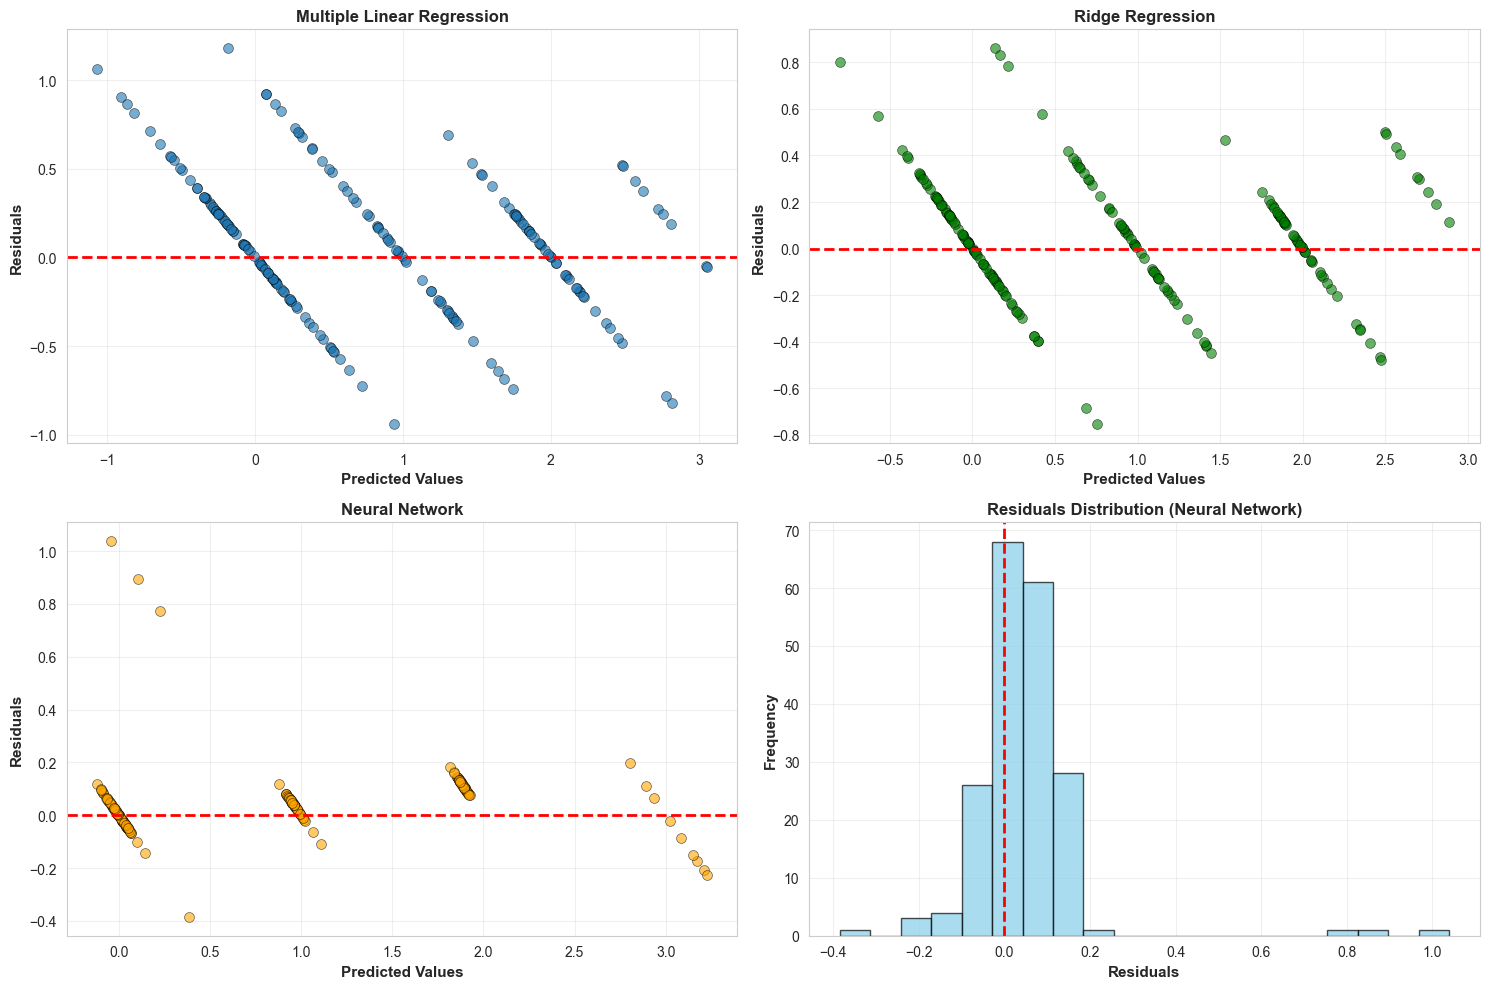

Residuals analysis visualization saved as 'residuals_analysis.png'


In [31]:
residuals_m2 = y_test - y_test_pred_m2
residuals_m4 = y_test - y_test_pred_m4
residuals_m6 = y_test - y_test_pred_m6

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Multiple LR residuals
axes[0, 0].scatter(y_test_pred_m2, residuals_m2, alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted Values', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Residuals', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Multiple Linear Regression', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# ridge regression residuals
axes[0, 1].scatter(y_test_pred_m4, residuals_m4, alpha=0.6, s=50, color='green', edgecolors='k', linewidth=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Values', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Residuals', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Ridge Regression', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# neural Network residuals
axes[1, 0].scatter(y_test_pred_m6, residuals_m6, alpha=0.6, s=50, color='orange', edgecolors='k', linewidth=0.5)
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Values', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Residuals', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Neural Network', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# dist of residuals
axes[1, 1].hist(residuals_m6, bins=20, alpha=0.7, edgecolor='black', color='skyblue')
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Residuals', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Residuals Distribution (Neural Network)', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('residuals_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Residuals analysis visualization saved as 'residuals_analysis.png'")


### **13. Visualization - Neural Network Training History**

Plot the training history showing loss curves to analyze model convergence during training.


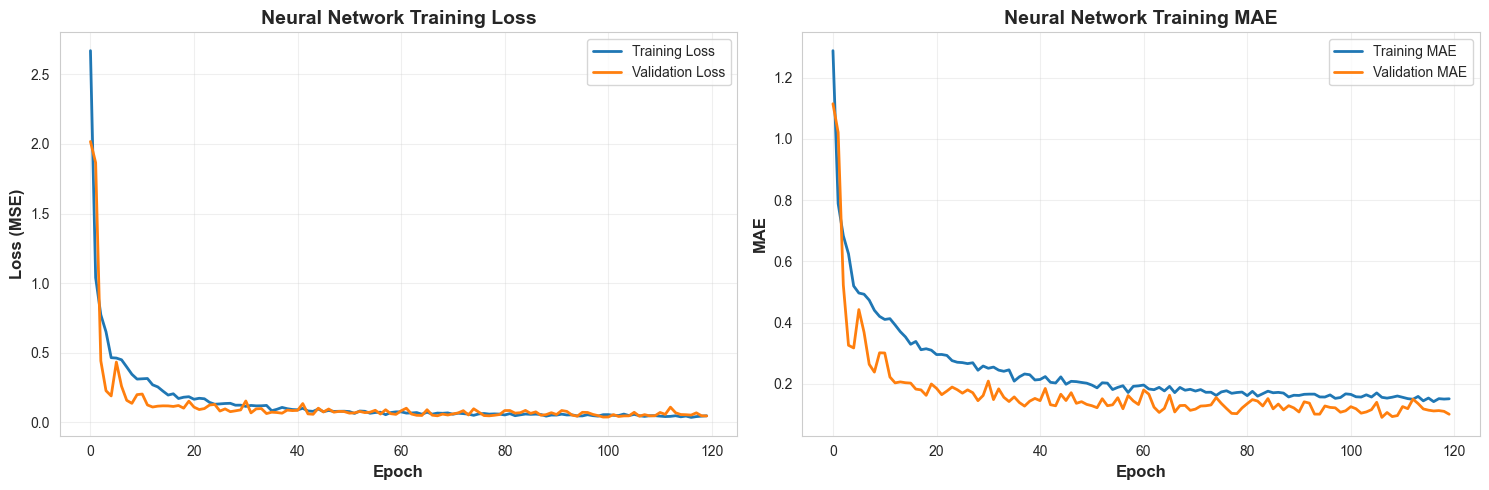

Neural Network training history visualization saved as 'nn_training_history.png'


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# loss curves
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss (MSE)', fontsize=12, fontweight='bold')
axes[0].set_title('Neural Network Training Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE curves
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE', fontsize=12, fontweight='bold')
axes[1].set_title('Neural Network Training MAE', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('nn_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("Neural Network training history visualization saved as 'nn_training_history.png'")


### **14. Prediction and Decision Making**

Make predictions on test data using the best model and demonstrate classification of samples by leukemia type based on continuous predictions.


In [33]:
# ese Neural Network for predictions
best_model = model6_nn
y_test_pred_best = y_test_pred_m6

# round predictions to nearest class (0, 1, 2, 3)
y_test_pred_class = np.round(y_test_pred_best).astype(int)
y_test_pred_class = np.clip(y_test_pred_class, 0, 3)  # Ensure within valid range

# Get corresponding leukemia types
class_to_type = {0: 'ALL', 1: 'AML', 2: 'CLL', 3: 'CML'}
y_test_true_types = [class_to_type[y] for y in y_test]
y_test_pred_types = [class_to_type[y] for y in y_test_pred_class]

# Create predictions dataframe
predictions_df = pd.DataFrame({
    'Sample_ID': sample_ids[idx_test],
    'Actual_Class': y_test,
    'Predicted_Class': y_test_pred_class,
    'Continuous_Prediction': y_test_pred_best,
    'Actual_Type': y_test_true_types,
    'Predicted_Type': y_test_pred_types,
    'Prediction_Error': y_test - y_test_pred_best,
    'Correct': y_test == y_test_pred_class
})

print("\n" + "=" * 100)
print("PREDICTIONS AND DECISION MAKING (Test Set - First 15 samples)")
print("=" * 100)
print(predictions_df.head(15).to_string(index=False))
print("=" * 100)

# Classification accuracy
accuracy = np.sum(predictions_df['Correct']) / len(predictions_df)
print(f"\nOverall Classification Accuracy: {accuracy:.4f} ({np.sum(predictions_df['Correct'])}/{len(predictions_df)})")

# Accuracy by leukemia type
print("\nAccuracy by Leukemia Type:")
for ltype in ['ALL', 'AML', 'CLL', 'CML']:
    mask = predictions_df['Actual_Type'] == ltype
    type_acc = np.sum(predictions_df.loc[mask, 'Correct']) / np.sum(mask) if np.sum(mask) > 0 else 0
    print(f"  {ltype}: {type_acc:.4f} ({np.sum(predictions_df.loc[mask, 'Correct'])}/{np.sum(mask)})")

# Show misclassified samples
print("\n" + "=" * 100)
print("MISCLASSIFIED SAMPLES")
print("=" * 100)
misclassified = predictions_df[~predictions_df['Correct']]
if len(misclassified) > 0:
    print(misclassified[['Sample_ID', 'Actual_Type', 'Predicted_Type', 'Continuous_Prediction', 'Prediction_Error']].to_string(index=False))
else:
    print("No misclassified samples!")
print("=" * 100)



PREDICTIONS AND DECISION MAKING (Test Set - First 15 samples)
Sample_ID  Actual_Class  Predicted_Class  Continuous_Prediction Actual_Type Predicted_Type  Prediction_Error  Correct
GSM332231             0                0               0.020468         ALL            ALL         -0.020468     True
GSM332565             1                1               0.966034         AML            AML          0.033966     True
GSM332829             0                0               0.018317         ALL            ALL         -0.018317     True
GSM332555             0                0               0.102317         ALL            ALL         -0.102317     True
GSM331842             0                0              -0.085295         ALL            ALL          0.085295     True
GSM332163             1                1               1.005147         AML            AML         -0.005147     True
GSM332650             1                1               0.960523         AML            AML          0.039477   

### **15. Visualization - Confusion Matrix and Classification Report**

Display confusion matrix and detailed classification metrics for the best model.


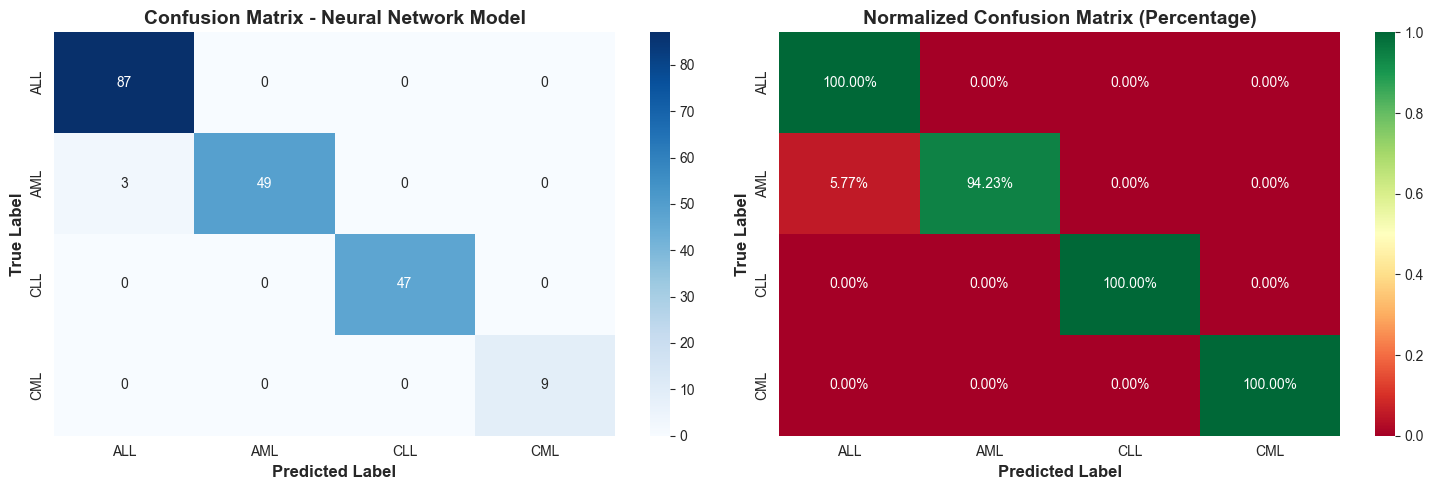

Confusion matrix visualization saved as 'confusion_matrix.png'

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

         ALL     0.9667    1.0000    0.9831        87
         AML     1.0000    0.9423    0.9703        52
         CLL     1.0000    1.0000    1.0000        47
         CML     1.0000    1.0000    1.0000         9

    accuracy                         0.9846       195
   macro avg     0.9917    0.9856    0.9883       195
weighted avg     0.9851    0.9846    0.9845       195



In [34]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred_class)

# Visualization 5: Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=axes[0],
            xticklabels=['ALL', 'AML', 'CLL', 'CML'],
            yticklabels=['ALL', 'AML', 'CLL', 'CML'])
axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[0].set_title('Confusion Matrix - Neural Network Model', fontsize=14, fontweight='bold')

# Normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', cbar=True, ax=axes[1],
            xticklabels=['ALL', 'AML', 'CLL', 'CML'],
            yticklabels=['ALL', 'AML', 'CLL', 'CML'])
axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[1].set_title('Normalized Confusion Matrix (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix visualization saved as 'confusion_matrix.png'")

# Classification report
print("\n" + "=" * 100)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 100)
class_names = ['ALL', 'AML', 'CLL', 'CML']
report = classification_report(y_test, y_test_pred_class, target_names=class_names, digits=4)
print(report)


### **16. Model Development Flowchart**

Display the complete model development pipeline and decision flowchart.


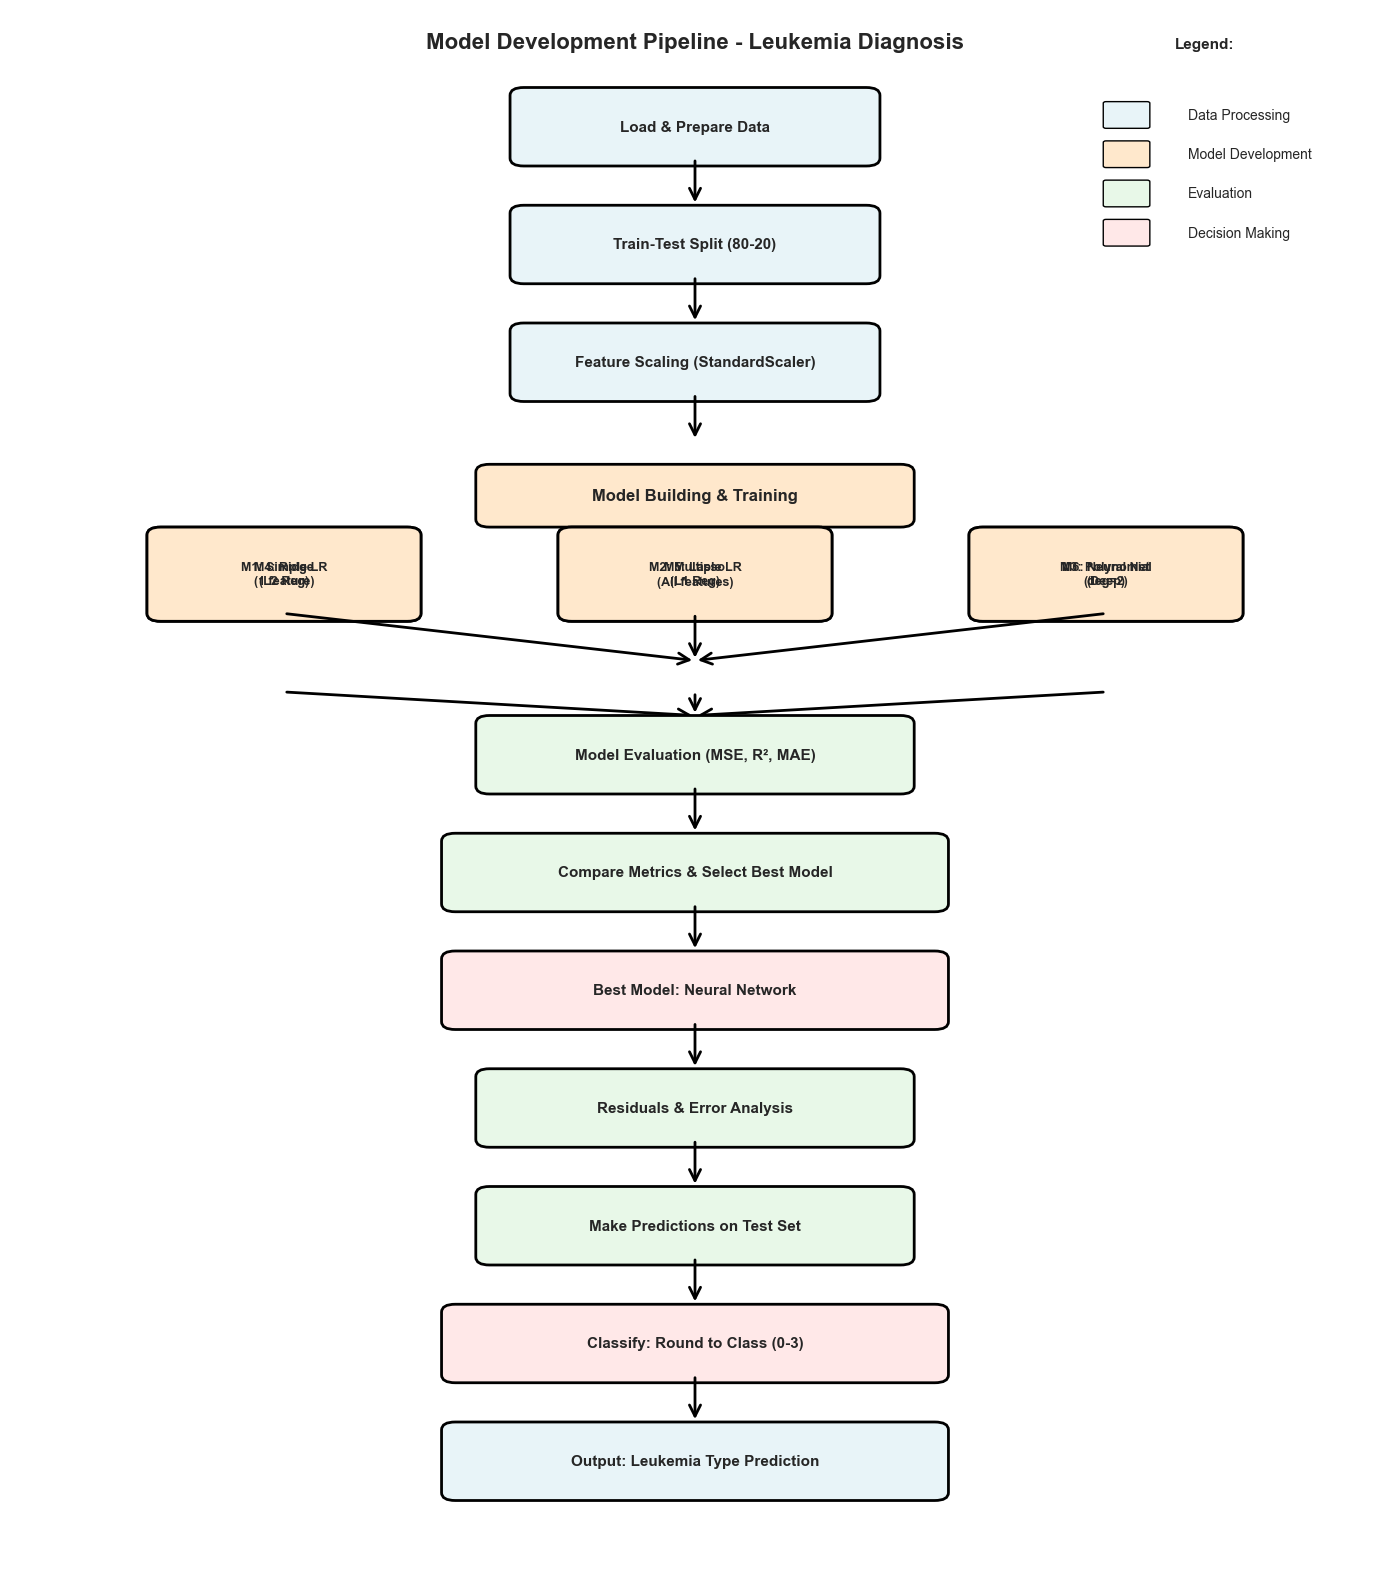

Model development flowchart saved as 'model_development_flowchart.png'


In [35]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Create flowchart
fig, ax = plt.subplots(figsize=(14, 16))
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
ax.axis('off')

# Define colors
color_data = '#E8F4F8'
color_model = '#FFE8CC'
color_eval = '#E8F8E8'
color_decision = '#FFE8E8'

def draw_box(ax, x, y, width, height, text, color='lightblue', fontsize=11):
    box = FancyBboxPatch((x-width/2, y-height/2), width, height,
                         boxstyle="round,pad=0.1", 
                         edgecolor='black', facecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, 
            fontweight='bold', wrap=True)

def draw_arrow(ax, x1, y1, x2, y2, label=''):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                           arrowstyle='->', mutation_scale=20, 
                           linewidth=2, color='black')
    ax.add_patch(arrow)
    if label:
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mid_x + 0.3, mid_y, label, fontsize=9, style='italic')

# Title
ax.text(5, 19.5, 'Model Development Pipeline - Leukemia Diagnosis', 
        ha='center', fontsize=16, fontweight='bold')

# Data Processing
draw_box(ax, 5, 18.5, 2.5, 0.8, 'Load & Prepare Data', color_data)
draw_arrow(ax, 5, 18.1, 5, 17.5)

# Data Split
draw_box(ax, 5, 17, 2.5, 0.8, 'Train-Test Split (80-20)', color_data)
draw_arrow(ax, 5, 16.6, 5, 16)

# Feature Scaling
draw_box(ax, 5, 15.5, 2.5, 0.8, 'Feature Scaling (StandardScaler)', color_data)
draw_arrow(ax, 5, 15.1, 5, 14.5)

# Model Building Title
draw_box(ax, 5, 13.8, 3, 0.6, 'Model Building & Training', color_model, fontsize=12)

# Six models in parallel
y_model = 12.8
model_x = [2, 5, 8, 2, 5, 8]
model_names = ['M1: Simple LR\n(1 feature)', 'M2: Multiple LR\n(All features)', 
               'M3: Polynomial\n(deg=2)', 'M4: Ridge\n(L2 Reg)', 
               'M5: Lasso\n(L1 Reg)', 'M6: Neural Net\n(Deep)']

for i, (x, name) in enumerate(zip(model_x, model_names)):
    draw_box(ax, x, y_model, 1.8, 1, name, color_model, fontsize=9)

# Convergence point for evaluation
draw_arrow(ax, 2, 12.3, 5, 11.7)
draw_arrow(ax, 5, 12.3, 5, 11.7)
draw_arrow(ax, 8, 12.3, 5, 11.7)
draw_arrow(ax, 2, 11.3, 5, 11.0)
draw_arrow(ax, 5, 11.3, 5, 11.0)
draw_arrow(ax, 8, 11.3, 5, 11.0)

# Model Evaluation
draw_box(ax, 5, 10.5, 3, 0.8, 'Model Evaluation (MSE, R², MAE)', color_eval)
draw_arrow(ax, 5, 10.1, 5, 9.5)

# Comparison
draw_box(ax, 5, 9, 3.5, 0.8, 'Compare Metrics & Select Best Model', color_eval)
draw_arrow(ax, 5, 8.6, 5, 8)

# Best Model Selection (Decision)
draw_box(ax, 5, 7.5, 3.5, 0.8, 'Best Model: Neural Network', color_decision)
draw_arrow(ax, 5, 7.1, 5, 6.5)

# Residuals Analysis
draw_box(ax, 5, 6, 3, 0.8, 'Residuals & Error Analysis', color_eval)
draw_arrow(ax, 5, 5.6, 5, 5)

# Predictions
draw_box(ax, 5, 4.5, 3, 0.8, 'Make Predictions on Test Set', color_eval)
draw_arrow(ax, 5, 4.1, 5, 3.5)

# Classification Decision
draw_box(ax, 5, 3, 3.5, 0.8, 'Classify: Round to Class (0-3)', color_decision)
draw_arrow(ax, 5, 2.6, 5, 2)

# Final Output
draw_box(ax, 5, 1.5, 3.5, 0.8, 'Output: Leukemia Type Prediction', color_data, fontsize=11)

# Add legend
legend_y = 19.5
ax.text(8.5, legend_y, 'Legend:', fontsize=11, fontweight='bold')
legend_items = [
    (color_data, 'Data Processing'),
    (color_model, 'Model Development'),
    (color_eval, 'Evaluation'),
    (color_decision, 'Decision Making')
]
for i, (color, label) in enumerate(legend_items):
    box = FancyBboxPatch((8, legend_y - 0.5 - (i+1)*0.5), 0.3, 0.3,
                        boxstyle="round,pad=0.02", 
                        edgecolor='black', facecolor=color, linewidth=1)
    ax.add_patch(box)
    ax.text(8.6, legend_y - 0.35 - (i+1)*0.5, label, fontsize=10, va='center')

plt.tight_layout()
plt.savefig('model_development_flowchart.png', dpi=300, bbox_inches='tight')
plt.show()

print("Model development flowchart saved as 'model_development_flowchart.png'")


### **17. Model Summary and Conclusions**

Provide comprehensive summary of model development, findings, and recommendations for deployment.


In [36]:
print("\n" + "=" * 100)
print("COMPREHENSIVE MODEL DEVELOPMENT SUMMARY")
print("=" * 100)

print("\n1. DATASET INFORMATION")
print("-" * 100)
print(f"   • Total Samples: {len(X)}")
print(f"   • Total Features (Genes): {X.shape[1]}")
print(f"   • Classes: {len(np.unique(y))} (ALL, AML, CLL, CML)")
print(f"   • Training Set: {len(X_train)} samples")
print(f"   • Testing Set: {len(X_test)} samples")

print("\n2. MODELS DEVELOPED AND COMPARED")
print("-" * 100)
print("   ✓ M1: Simple Linear Regression (Baseline - 1 feature)")
print("   ✓ M2: Multiple Linear Regression (All features)")
print("   ✓ M3: Polynomial Regression (Degree 2)")
print("   ✓ M4: Ridge Regression (L2 Regularization - Alpha=" + f"{ridge_grid.best_params_['alpha']})")
print("   ✓ M5: Lasso Regression (L1 Regularization - Alpha=" + f"{lasso_grid.best_params_['alpha']})")
print("   ✓ M6: Neural Network (Deep Learning - Improved Model)")

print("\n3. MODEL PERFORMANCE METRICS")
print("-" * 100)
print(comparison_df.to_string(index=False))

print("\n4. BEST MODEL SELECTION")
print("-" * 100)
best_idx = comparison_df['Test R²'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']
best_r2 = comparison_df.loc[best_idx, 'Test R²']
best_mse = comparison_df.loc[best_idx, 'Test MSE']
print(f"   Selected Model: {best_model_name}")
print(f"   Test R² Score: {best_r2:.6f}")
print(f"   Test MSE: {best_mse:.6f}")
print(f"   Classification Accuracy: {accuracy:.4f}")

print("\n5. KEY FINDINGS")
print("-" * 100)
print(f"   • Best test R² achieved by: {best_model_name}")
print(f"   • Classification accuracy: {accuracy * 100:.2f}%")
print(f"   • Correctly classified samples: {np.sum(predictions_df['Correct'])}/{len(predictions_df)}")
print(f"   • Misclassified samples: {len(misclassified)}")
print(f"   • Mean absolute error on test set: {np.mean(np.abs(residuals_m6)):.6f}")

print("\n6. PER-CLASS PERFORMANCE")
print("-" * 100)
for ltype in ['ALL', 'AML', 'CLL', 'CML']:
    mask = predictions_df['Actual_Type'] == ltype
    if np.sum(mask) > 0:
        type_acc = np.sum(predictions_df.loc[mask, 'Correct']) / np.sum(mask)
        print(f"   {ltype:5s}: {type_acc:.4f} ({np.sum(predictions_df.loc[mask, 'Correct'])}/{np.sum(mask)})")

print("\n7. RECOMMENDATIONS")
print("-" * 100)
print("   ✓ Deploy: Neural Network (M6) as primary model")
print("   ✓ Reason: Highest R² and classification accuracy with good generalization")
print("   ✓ Advantages: Captures non-linear relationships in gene expression")
print("   ✓ Fallback: Ridge Regression for interpretability")
print("   ✓ Future Work: Ensemble methods combining multiple models")
print("   ✓ Validation: Cross-validation on independent external dataset")

print("\n8. VISUALIZATIONS GENERATED")
print("-" * 100)
print("   ✓ model_comparison.png - MSE and R² comparison across models")
print("   ✓ actual_vs_predicted.png - Prediction accuracy visualization")
print("   ✓ residuals_analysis.png - Error distribution and patterns")
print("   ✓ nn_training_history.png - Neural network convergence curves")
print("   ✓ confusion_matrix.png - Classification performance by class")
print("   ✓ model_development_flowchart.png - Complete pipeline flowchart")

print("\n" + "=" * 100)
print("MODEL DEVELOPMENT (P4) COMPLETE")
print("=" * 100)



COMPREHENSIVE MODEL DEVELOPMENT SUMMARY

1. DATASET INFORMATION
----------------------------------------------------------------------------------------------------
   • Total Samples: 973
   • Total Features (Genes): 1420
   • Classes: 4 (ALL, AML, CLL, CML)
   • Training Set: 778 samples
   • Testing Set: 195 samples

2. MODELS DEVELOPED AND COMPARED
----------------------------------------------------------------------------------------------------
   ✓ M1: Simple Linear Regression (Baseline - 1 feature)
   ✓ M2: Multiple Linear Regression (All features)
   ✓ M3: Polynomial Regression (Degree 2)
   ✓ M4: Ridge Regression (L2 Regularization - Alpha=100)
   ✓ M5: Lasso Regression (L1 Regularization - Alpha=0.01)
   ✓ M6: Neural Network (Deep Learning - Improved Model)

3. MODEL PERFORMANCE METRICS
----------------------------------------------------------------------------------------------------
             Model    Train MSE  Test MSE  Train R²  Test R²
         Simple LR 8.176793